<center><h1> IFT-6758  Data Science  </h1></center>
<center><h2> Fall - 2020 </h2></center> 
<center><h3> Lab - Week 10</h3></center> 
<center><h3> </h3></center> 
<center><h3> Deep Learning using Keras</h3></center> 





**Keras** (κέρας) means horn in Greek. It is a reference to a literary image from ancient Greek and Latin literature, first found in the Odyssey, where there is mention about those who announce a future that will come to pass arriving through a gate of horn. It's a play on the words κέρας (horn) / κραίνω (fulfill).

Keras was initially developed as part of the research effort of project ONEIROS (Open-ended Neuro-Electronic Intelligent Robot Operating System). Its primary author and maintainer is [François Chollet](https://fchollet.com/).

### Installation
On Google colab `keras` is already installed

In [ ]:
!pip install keras

In [ ]:
import keras
# %tensorflow_version 1.x 


### Backend

* Keras is a model-level library, providing high-level building blocks for developing deep learning models. 
* It does not handle low-level operations such as tensor products, convolutions and so on itself. 
* It relies on a specialized, well optimized tensor manipulation library to do so, serving as the "backend engine". Rather than picking one single tensor library and making the implementation of Keras tied to that library, Keras handles the problem in a modular way, and several different backend engines can be plugged seamlessly into Keras.

At this time, Keras has three backend implementations available: the TensorFlow backend, the Theano backend, and the CNTK backend.

![https://miro.medium.com/max/834/1*OxAgYCBDKyXYLiWWUoKUcQ.png](https://miro.medium.com/max/834/1*OxAgYCBDKyXYLiWWUoKUcQ.png)

[Source : Parul Pandey's [blog](https://towardsdatascience.com/my-journey-into-deeplearning-using-keras-part-1-67cbb50f65e6)]

In [ ]:
keras.backend.backend()

'tensorflow'

![https://www.kdnuggets.com/wp-content/uploads/keras-4-step-workflow.png](https://www.kdnuggets.com/wp-content/uploads/keras-4-step-workflow.png)

[Source : KDnuggets [site](https://www.kdnuggets.com/2018/06/keras-4-step-workflow.html)]


# Example 1

## Boston Housing Dataset


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import boston_housing
 


 # Prepare the dataset
(X_train, Y_train), (X_test, Y_test) = boston_housing.load_data()
 
num_features = X_train.shape[1]

57344/57026 [==============================] - 0s 0us/step


In [ ]:
num_features

13

## Model Creation

In [ ]:
 # Define model
model = Sequential()
model.add(Dense(1, activation='linear', input_shape=(num_features,)))

# View model
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 1)                 14        
Total params: 14
Trainable params: 14
Non-trainable params: 0
_________________________________________________________________


## Training

In [ ]:
# opt = keras.optimizers.Adam(learning_rate=0.001)
# model.compile(optimizer=opt, loss='mse', metrics=['mse', 'mae'])
model.compile(optimizer='rmsprop', loss='mse', metrics=['mse', 'mae'])

In [ ]:
model.fit(X_train, Y_train, batch_size=4, epochs=100)

Epoch 1/100
101/101 [==============================] - 0s 2ms/step - loss: 26.0537 - mse: 26.0537 - mae: 3.5956
Epoch 2/100
101/101 [==============================] - 0s 2ms/step - loss: 26.6219 - mse: 26.6219 - mae: 3.6202
Epoch 3/100
101/101 [==============================] - 0s 2ms/step - loss: 26.1750 - mse: 26.1750 - mae: 3.6268
Epoch 4/100
101/101 [==============================] - 0s 2ms/step - loss: 25.7975 - mse: 25.7975 - mae: 3.5156
Epoch 5/100
101/101 [==============================] - 0s 2ms/step - loss: 25.9628 - mse: 25.9628 - mae: 3.6030
Epoch 6/100
101/101 [==============================] - 0s 2ms/step - loss: 25.5642 - mse: 25.5642 - mae: 3.6371
Epoch 7/100
101/101 [==============================] - 0s 2ms/step - loss: 26.3151 - mse: 26.3151 - mae: 3.5604
Epoch 8/100
101/101 [==============================] - 0s 2ms/step - loss: 26.1333 - mse: 26.1333 - mae: 3.5816
Epoch 9/100
101/101 [==============================] - 0s 2ms/step - loss: 26.1126 - mse: 26.1126 - mae:

In [ ]:
model.weights[0]

<tf.Variable 'dense_3/kernel:0' shape=(13, 1) dtype=float32, numpy=
array([[-1.03959925e-01],
       [ 7.22751319e-02],
       [-5.40478379e-02],
       [ 4.65349817e+00],
       [ 8.28058124e-01],
       [ 4.68153858e+00],
       [ 4.22202563e-03],
       [-1.08429682e+00],
       [ 2.03123316e-01],
       [-8.91115516e-03],
       [-1.79607153e-01],
       [ 1.88714880e-02],
       [-5.18766463e-01]], dtype=float32)>

In [ ]:
model.weights[1]

<tf.Variable 'dense_3/bias:0' shape=(1,) dtype=float32, numpy=array([3.1952286], dtype=float32)>

In [ ]:
model.evaluate(X_train, Y_train)

13/13 [==============================] - 0s 2ms/step - loss: 3512.3657 - mse: 3512.3657 - mae: 48.2319


[3512.36572265625, 3512.36572265625, 48.23194885253906]

In [ ]:
model.evaluate(X_test, Y_test)

4/4 [==============================] - 0s 4ms/step - loss: 3597.7788 - mse: 3597.7788 - mae: 50.7194


[3597.77880859375, 3597.77880859375, 50.71941375732422]

## Similarity with Sklearn

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
reg = LinearRegression()
reg.fit(X_train, Y_train)


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
Y_pred = reg.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import math
mse = mean_squared_error(Y_test, Y_pred)
print(f"MSE -> {mse}")

MSE -> 23.195599256422906


In [ ]:
bias = reg.intercept_
weights = reg.coef_ 

print(f"Weights -> {weights}")
print(f"Bias -> {bias}")

Weights -> [-1.19997513e-01  5.70003304e-02  3.98379660e-03  4.12698187e+00
 -2.05002963e+01  3.38024903e+00  7.56807584e-03 -1.71189793e+00
  3.34747537e-01 -1.17797225e-02 -9.02318039e-01  8.71912756e-03
 -5.55842510e-01]
Bias -> 40.29367058057704


![https://www.learnopencv.com/wp-content/uploads/2017/09/keras-workflow.jpg](https://www.learnopencv.com/wp-content/uploads/2017/09/keras-workflow.jpg)

[Source : Learn OpenCV [site](https://www.learnopencv.com/deep-learning-using-keras-the-basics/)]

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

# Data
data = np.random.random((1000,100))
labels = np.random.randint(2,size=(1000,1))

# Define network (model)
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=100))
model.add(Dense(1, activation='sigmoid'))

# Configure training
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# Fit model by training
model.fit(data,labels,epochs=10,batch_size=32)

# Make predictions

predictions = model.predict(data)

Epoch 1/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6985 - accuracy: 0.5120
Epoch 2/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6923 - accuracy: 0.5250
Epoch 3/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6841 - accuracy: 0.5570
Epoch 4/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6795 - accuracy: 0.5460
Epoch 5/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6776 - accuracy: 0.5610
Epoch 6/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6712 - accuracy: 0.5880
Epoch 7/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6693 - accuracy: 0.5980
Epoch 8/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6616 - accuracy: 0.6220
Epoch 9/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6645 - accuracy: 0.6050
Epoch 10/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6574 - accuracy: 0.6170


# Example 2

Taken from [Joseph Lee](https://github.com/josephlee94/intuitive-deep-learning/blob/master/Part%202:%20Image%20Recognition%20CIFAR-10/Coding%20Companion%20to%20Intuitive%20Deep%20Learning%20Part%202%20(Annotated).ipynb)

The medium post for this notebook is [here](https://medium.com/@josephleeweien/build-your-first-convolutional-neural-network-to-recognize-images-84b9c78fe0ce).

In this notebook, we'll go through the code for the coding companion for [Intuitive Deep Learning Part 2](https://medium.com/intuitive-deep-learning/intuitive-deep-learning-part-2-cnns-for-computer-vision-24992d050a27) to create your very first Convolutional neural network to predict what is contained within the image (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck). We will go through the following in this notebook:

- Exploring and Processing the Data
- Building and Training our Convolutional Neural Network
- Testing out with your own images

Note that the results you get might differ slightly from the blogpost as there is a degree of randomness in the way we split our dataset as well as the initialization of our neural network.


### CIFAR-10 dataset




In [ ]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 8s 0us/step


### Exploring Datasets

In [ ]:
print('x_train shape:', x_train.shape)

x_train shape: (50000, 32, 32, 3)


In [ ]:
print('y_train shape:', y_train.shape)

y_train shape: (50000, 1)


We will now take a look at an individual image. If we print out the first image 


In [ ]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In order to see the image as an image rather than a series of pixel value numbers, we will use a function from matplotlib:

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

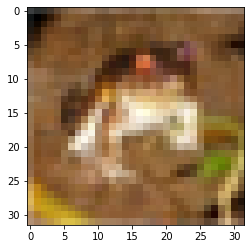

In [ ]:
img = plt.imshow(x_train[0])

In [ ]:
print('The label is:', y_train[0])

The label is: [6]


Let's explore one more image, the second image (with index 1 instead of 0) in our training dataset:

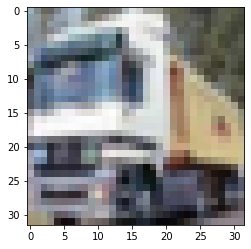

In [ ]:
img = plt.imshow(x_train[1])

In [ ]:
print('The label is:', y_train[1])

The label is: [9]


## Pre-processing Datasets

What we really want is the probability of each of the 10 different classes. For that, we need 10 output neurons in our neural network. Since we have 10 output neurons, our labels must match this as well. To do this, we convert the label into a set of 10 numbers where each number represents if the image belongs to that class or not. So if an image belongs to the first class, the first number of this set will be a 1 and all other numbers in this set will be a 0. To convert our labels to our one-hot encoding, we use a function in Keras:

In [ ]:
import keras
y_train_one_hot = keras.utils.to_categorical(y_train, 10)
y_test_one_hot = keras.utils.to_categorical(y_test, 10)

In [ ]:
print('The one hot label is:', y_train_one_hot[1])

The one hot label is: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
y_train_one_hot[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32)

A common step we do is to let the values to be between 0 and 1, which will aid in the training of our neural network. Since our pixel values already take the values between 0 and 255, we simply need to divide by 255.

In [ ]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
x_train[0]

array([[[0.23137255, 0.24313726, 0.24705882],
        [0.16862746, 0.18039216, 0.1764706 ],
        [0.19607843, 0.1882353 , 0.16862746],
        ...,
        [0.61960787, 0.5176471 , 0.42352942],
        [0.59607846, 0.49019608, 0.4       ],
        [0.5803922 , 0.4862745 , 0.40392157]],

       [[0.0627451 , 0.07843138, 0.07843138],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509805, 0.21568628],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117648, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215687, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941177, 0.19607843],
        [0.47058824, 0.32941177, 0.19607843],
        [0.42745098, 0.28627452, 0.16470589]],

       ...,

       [[0.8156863 , 0.6666667 , 0.3764706 ],
        [0.7882353 , 0.6       , 0.13333334],
        [0.7764706 , 0

## Model Creation - CNN

Similar to our first notebook, we need to define the architecture (template) first before fitting the best numbers into this architecture by learning from the data. In summary, the architecture we will build in this post is this:

- Conv Layer (Filter size 3x3, Depth 32)
- Conv Layer (Filter size 3x3, Depth 32)
- Max Pool Layer (Filter size 2x2)
- Dropout Layer (Prob of dropout 0.25)
- Conv Layer (Filter size 3x3, Depth 64)
- Conv Layer (Filter size 3x3, Depth 64)
- Max Pool Layer (Filter size 2x2)
- Dropout Layer (Prob of dropout 0.25)
- FC Layer (512 neurons)
- Dropout Layer (Prob of dropout 0.5)
- FC Layer, Softmax (10 neurons)

For an intuition behind these layers, please refer to Intuitive Deep Learning [Part 2](https://medium.com/intuitive-deep-learning/intuitive-deep-learning-part-2-cnns-for-computer-vision-24992d050a27).

We will be using Keras to build our architecture. Let's import the code from Keras that we will need to use:

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

We then call an empty Sequential model and 'add' to this model layer by layer:

In [ ]:
model = Sequential()

The first layer is a conv layer with filter size 3x3, stride size 1 (in both dimensions), and depth 32. The padding is the 'same' and the activation is 'relu' (these two settings will apply to all layers in our CNN). We add this layer to our empty sequential model using the function model.add().

The first number 32 refers to the depth. The next pair of numbers (3,3) refer to the filter width and size. Then, we specify activation which is 'relu' and padding which is 'same'. Notice that we did not specify stride. This is because stride=1 is a default setting, and unless we want to change this setting, we need not specify it.

If you recall, we also need to specify an input size for our first layer; subsequent layers does not have this specification since they can infer the input size from the output size of the previous layer.

All that being said, our first layer in code looks like this:

In [ ]:
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32,32,3)))

Our second layer looks like this in code (we don't need to specify the input size):

In [ ]:
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))

The next layer is a max pooling layer with pool size 2 x 2 and stride 2 (in both dimensions). The default for a max pooling layer stride is the pool size, so we don't have to specify the stride:

In [ ]:
model.add(MaxPooling2D(pool_size=(2, 2)))

Lastly, we add a dropout layer with probability 0.25 of dropout so as to prevent overfitting:

In [ ]:
model.add(Dropout(0.25))

And there we have it, our first four layers in code. The next four layers look really similar (except the depth of the conv layer is 64 instead of 32):

In [ ]:
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

Lastly, we have to code in our fully connected layer, which is similar to what we've done in our previous post, [Build your first Neural Network](https://medium.com/intuitive-deep-learning/build-your-first-neural-network-to-predict-house-prices-with-keras-eb5db60232c). However, at this point, our neurons are spatially arranged in a cube-like format rather than in just one row. To make this cube-like format of neurons into one row, we have to first flatten it. We do so by adding a Flatten layer:

In [ ]:
model.add(Flatten())

Now, we have a dense (FC) layer of 512 neurons with relu activation:

In [ ]:
model.add(Dense(512, activation='relu'))

We add another dropout of probability 0.5:

In [ ]:
model.add(Dropout(0.5))

And lastly, we have a dense (FC) layer with 10 neurons and softmax activation:

In [ ]:
model.add(Dense(10, activation='softmax'))

And we're done with specifying our architecture! To see a summary of the full architecture, we run the code:

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 32, 32, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 32, 32, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 16, 16, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 16, 16, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 16, 16, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 8, 8, 64)         

We now fill in the best numbers after we've specified our architecture. We'll compile the model with our settings below.

The loss function we use is called categorical cross entropy, which is applicable for a classification problem of many classes. The optimizer we use here is Adam. We haven't gone through the intuition of Adam yet, but know that Adam is simply a type of stochastic gradient descent (with a few modifications) so that it trains better. Lastly, we want to track the accuracy of our model.

## Training

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

And now, it's time to run our training.

We train our model with batch size 32 and 20 epochs. We use the setting validation_split=0.2 instead of validation_data. With this shortcut, we did not need to split our dataset into a train and validation set at the start! Instead, we simply specify how much of our dataset will be used as a validation set. In this case, 20% of our dataset is used as a validation set. This will take a while on a CPU, so you might want to start training and get some coffee before coming back.

In [ ]:
hist = model.fit(x_train, y_train_one_hot, 
           batch_size=32, epochs=10, 
           validation_split=0.2)

Epoch 1/10
1250/1250 [==============================] - 6s 5ms/step - loss: 2.2215 - accuracy: 0.3282 - val_loss: 1.4943 - val_accuracy: 0.4691
Epoch 2/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.4633 - accuracy: 0.4762 - val_loss: 1.3001 - val_accuracy: 0.5460
Epoch 3/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.2978 - accuracy: 0.5374 - val_loss: 1.1789 - val_accuracy: 0.5890
Epoch 4/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.1971 - accuracy: 0.5770 - val_loss: 1.0349 - val_accuracy: 0.6324
Epoch 5/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.1342 - accuracy: 0.6039 - val_loss: 1.0390 - val_accuracy: 0.6402
Epoch 6/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.0755 - accuracy: 0.6275 - val_loss: 0.9847 - val_accuracy: 0.6597
Epoch 7/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.0336 - accuracy: 0.6391 - val_loss: 1.0087 - val_accuracy:

After you've done training, we can visualize the model training and validation loss as well as training / validation accuracy over the number of epochs using the below code:

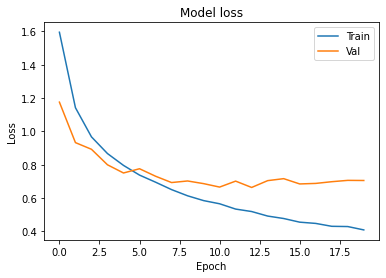

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

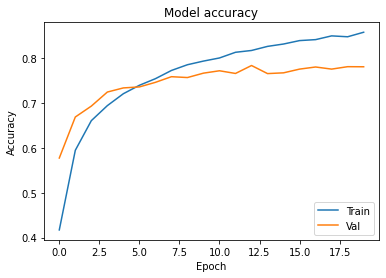

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

Once we are done with tweaking our hyperparameters, we can run it on our test dataset below:

In [ ]:
model.evaluate(x_test, y_test_one_hot)[1]

313/313 [==============================] - 1s 3ms/step - loss: 0.7457 - accuracy: 0.7733


0.7732999920845032

At this point, you might want to save your trained model (since you've spent so long waiting for it to train). The model will be saved in a file format called HDF5 (with the extension .h5). We save our model with this line of code:

In [ ]:
model.save('my_cifar10_model.h5')

## Testing with images






Now that we have a model, let's try it on our own images. To do so, place your image in the same directory as your notebook. For the purposes of this post, I'm going to use an image of a cat (which you can download here(link [link text](https://www.google.com/imgres?imgurl=https%3A%2F%2Fc.files.bbci.co.uk%2F12A9B%2Fproduction%2F_111434467_gettyimages-1143489763.jpg&imgrefurl=https%3A%2F%2Fwww.bbc.com%2Fnews%2Fuk-england-stoke-staffordshire-52047832&tbnid=Um0YBjHrLfxXfM&vet=12ahUKEwi8wMKC5OXsAhWDjuAKHSYEAQQQMygAegUIARDOAQ..i&docid=vehskR6bZeyrDM&w=976&h=549&q=cat&ved=2ahUKEwi8wMKC5OXsAhWDjuAKHSYEAQQQMygAegUIARDOAQ))). Now, we read in our JPEG file as an array of pixel values:

In [ ]:
my_image = plt.imread("cat.jpg")

The first thing we have to do is to resize the image of our cat so that we can fit it into our model (input size of 32 * 32 * 3).

In [ ]:
from skimage.transform import resize
my_image_resized = resize(my_image, (32,32,3))

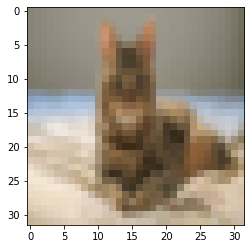

In [ ]:
img = plt.imshow(my_image_resized)

And now, we see what our trained model will output when given an image of our cat, using this code:

In [ ]:
import numpy as np
probabilities = model.predict(np.array( [my_image_resized,] ))

In [ ]:
probabilities

array([[1.1300937e-05, 8.7753193e-07, 1.3291774e-02, 8.0312896e-01,
        2.4045729e-03, 1.7325690e-01, 2.8059648e-03, 5.0610141e-03,
        3.6322268e-05, 2.3665000e-06]], dtype=float32)

In [ ]:
number_to_class = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
index = np.argsort(probabilities[0,:])
print("Most likely class:", number_to_class[index[9]], "-- Probability:", probabilities[0,index[9]])
print("Second most likely class:", number_to_class[index[8]], "-- Probability:", probabilities[0,index[8]])
print("Third most likely class:", number_to_class[index[7]], "-- Probability:", probabilities[0,index[7]])
print("Fourth most likely class:", number_to_class[index[6]], "-- Probability:", probabilities[0,index[6]])
print("Fifth most likely class:", number_to_class[index[5]], "-- Probability:", probabilities[0,index[5]])

Most likely class: cat -- Probability: 0.80312896
Second most likely class: dog -- Probability: 0.1732569
Third most likely class: bird -- Probability: 0.013291774
Fourth most likely class: horse -- Probability: 0.005061014
Fifth most likely class: frog -- Probability: 0.0028059648


As you can see, the model has accurately predicted that this is indeed an image of a cat. Now, this isn't the best model we have and accuracy has been quite low, so don't expect too much out of it. This post has covered the very fundamentals of CNNs on a very simple dataset; we'll cover how to build state-of-the-art models in future posts. Nevertheless, you should be able to get some pretty cool results from your own images (some images that you can try this out on are in the GitHub folder).

# Example 3

### IMDB Dataset

Binary Classification, Multi-Classification, and Regression

In [ ]:
# Classifying movie reviews: a binary classification example
# The IMDB dataset
from keras.datasets import imdb
(train_data, train_labels),(test_data, test_labels) = imdb.load_data(num_words=10000)

17465344/17464789 [==============================] - 0s 0us/step


### Preprocessing Dataset

In [ ]:
# checking data
train_data[0]
train_data.max()
train_data

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [ ]:
word_index = imdb.get_word_index()
# reverse word
reverse_word_index = dict([(value,key) for (key,value) in word_index.items()])

decoded_review = ' '.join([reverse_word_index.get(i-3, '?') for i in train_data[0]])
decoded_review

1646592/1641221 [==============================] - 0s 0us/step


"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [ ]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
  """
  # one hot vectors + sparse matrices
  """
  results = np.zeros((len(sequences), dimension))
  for i,sequence in enumerate(sequences):
    results[i, sequence] = 1
  return results

x_train = vectorize_sequences(train_data)   
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

### Model Creation

In [ ]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
# two ways to set optimizer, loss, metrics 
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])

from keras import optimizers
from keras import losses
from keras import metrics
model.compile(optimizer=optimizers.RMSprop(lr=0.001),
             loss=losses.binary_crossentropy,metrics=[metrics.binary_accuracy])

### Training

In [ ]:
x_val = x_train[:10000]
partial_x_train = x_train[:10000]

y_val = y_train[:10000]
partial_y_train = y_train[:10000]

# model.fit() returns history and can check the info

history = model.fit(partial_x_train, partial_y_train, epochs=20,
                   batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
20/20 [==============================] - 1s 31ms/step - loss: 0.0061 - binary_accuracy: 0.9988 - val_loss: 0.0020 - val_binary_accuracy: 0.9998
Epoch 2/20
20/20 [==============================] - 0s 21ms/step - loss: 0.0020 - binary_accuracy: 0.9998 - val_loss: 0.0017 - val_binary_accuracy: 0.9998
Epoch 3/20
20/20 [==============================] - 0s 21ms/step - loss: 0.0017 - binary_accuracy: 0.9998 - val_loss: 0.0013 - val_binary_accuracy: 0.9998
Epoch 4/20
20/20 [==============================] - 0s 20ms/step - loss: 0.0013 - binary_accuracy: 0.9998 - val_loss: 0.0012 - val_binary_accuracy: 0.9998
Epoch 5/20
20/20 [==============================] - 0s 21ms/step - loss: 0.0039 - binary_accuracy: 0.9988 - val_loss: 6.8796e-04 - val_binary_accuracy: 1.0000
Epoch 6/20
20/20 [==============================] - 0s 21ms/step - loss: 6.5332e-04 - binary_accuracy: 0.9999 - val_loss: 5.1480e-04 - val_binary_accuracy: 1.0000
Epoch 7/20
20/20 [==============================] - 0s 21m

### Loss Curves

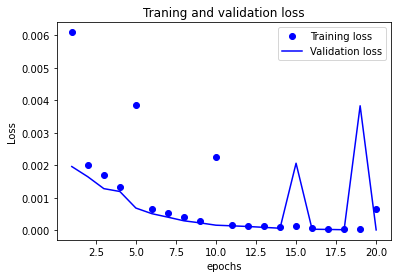

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Traning and validation loss')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

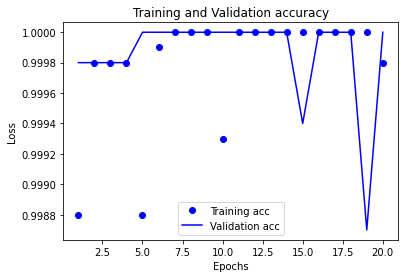

In [ ]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')

plt.title("Training and Validation accuracy")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# References

1.   Datacamp Keras [cheatsheet](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Keras_Cheat_Sheet_Python.pdf)
2.   Keras official [documentation](https://keras.io/)
3.   Parul Pandey's [blog](https://towardsdatascience.com/my-journey-into-deeplearning-using-keras-part-1-67cbb50f65e6)
4.   Hackernoon [blog](https://hackernoon.com/build-your-first-neural-network-to-predict-house-prices-with-keras-3fb0839680f4)
5.   Comparitive study of Deep Learning Frameworks : [paper](https://arxiv.org/pdf/1903.00102.pdf) - [table](https://en.wikipedia.org/wiki/Comparison_of_deep-learning_software) 
6.   Hyperparameter Search in Keras : [blog](https://machinelearningmastery.com/grid-search-hyperparameters-deep-learning-models-python-keras/)



# Exercise

1. Download the MNIST dataset.
2. Train the dataset using a Multi-Layer Perceptron.
3. Train the same training set using convolution neural networks.
4. Compare accuracy scores and loss curves of both models on the same test-set.   

# Solutions

In [ ]:
from keras.datasets import mnist

#download mnist data and split into train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


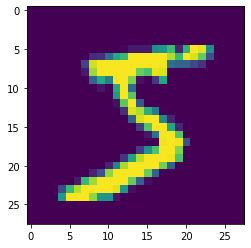

In [ ]:
import matplotlib.pyplot as plt

#plot the first image in the dataset
plt.imshow(X_train[0])

In [ ]:
#check image shape
X_train[0].shape

(28, 28)

In [ ]:
#reshape data to fit model
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

from keras.utils import to_categorical
#one-hot encode target column
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

## CNN

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten

#create model
model = Sequential()

#add model layers
model.add(Conv2D(64, kernel_size=3, activation="relu", input_shape=(28,28,1)))
model.add(Conv2D(32, kernel_size=3, activation="relu"))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

In [ ]:
#compile model using accuracy to measure model performance
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#train the model
history_cnn = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2373 - accuracy: 0.9484 - val_loss: 0.1032 - val_accuracy: 0.9673
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0734 - accuracy: 0.9769 - val_loss: 0.0786 - val_accuracy: 0.9739
Epoch 3/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0486 - accuracy: 0.9855 - val_loss: 0.0997 - val_accuracy: 0.9726
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0353 - accuracy: 0.9888 - val_loss: 0.0958 - val_accuracy: 0.9780
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0245 - accuracy: 0.9920 - val_loss: 0.1060 - val_accuracy: 0.9757


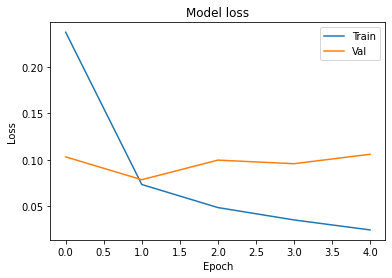

In [ ]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

## MLP

In [ ]:
#create model
model = Sequential()

#add model layers
model.add(Flatten(input_shape=(28,28,1)))
model.add(Dense(256, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_11 (Dense)             (None, 256)               200960    
_________________________________________________________________
dense_12 (Dense)             (None, 128)               32896     
_________________________________________________________________
dense_13 (Dense)             (None, 10)                1290      
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#train the model
history_mlp = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
1875/1875 [==============================] - 4s 2ms/step - loss: 1.4400 - accuracy: 0.8864 - val_loss: 0.3012 - val_accuracy: 0.9287
Epoch 2/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2354 - accuracy: 0.9387 - val_loss: 0.2099 - val_accuracy: 0.9442
Epoch 3/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1790 - accuracy: 0.9502 - val_loss: 0.2191 - val_accuracy: 0.9464
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1514 - accuracy: 0.9578 - val_loss: 0.1763 - val_accuracy: 0.9544
Epoch 5/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1337 - accuracy: 0.9631 - val_loss: 0.1616 - val_accuracy: 0.9597


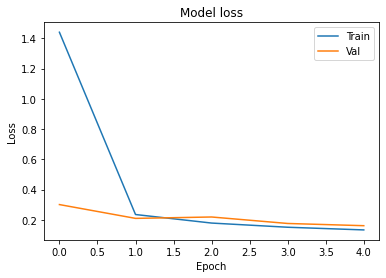

In [ ]:
plt.plot(history_mlp.history['loss'])
plt.plot(history_mlp.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

## Comparison

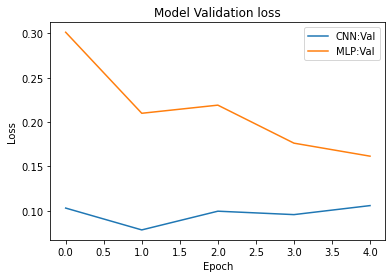

In [ ]:
plt.plot(history_cnn.history['val_loss'])
plt.plot(history_mlp.history['val_loss'])
plt.title('Model Validation loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['CNN:Val', 'MLP:Val'], loc='upper right')
plt.show()